In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,average_precision_score)

In [3]:
DATA_PATH = "../data/raw/telco_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

TARGET = "Churn Label"

y = df[TARGET].map({"No": 0,"Yes": 1})
X = df.drop(columns=[TARGET]).copy()
columns_to_drop = ["Count","Country","State","CustomerID","Churn Value","Churn Score","Churn Reason"]
X = X.drop(columns=columns_to_drop)
X["Total Charges"] = pd.to_numeric(X["Total Charges"],errors="coerce")
X.loc[(X["Tenure Months"] == 0) &(X["Total Charges"].isna()),"Total Charges"] = 0
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 25)
y shape: (7043,)


In [4]:
cardinality = (X.nunique().sort_values(ascending=False))
print(cardinality)

Total Charges        6531
CLTV                 3438
Lat Long             1652
Latitude             1652
Zip Code             1652
Longitude            1651
Monthly Charges      1585
City                 1129
Tenure Months          73
Payment Method          4
Tech Support            3
Online Backup           3
Device Protection       3
Streaming Movies        3
Multiple Lines          3
Internet Service        3
Online Security         3
Streaming TV            3
Contract                3
Senior Citizen          2
Gender                  2
Dependents              2
Partner                 2
Phone Service           2
Paperless Billing       2
dtype: int64


In [5]:
X_full = X.copy()
X_reduced = X.drop(columns=["City","Lat Long","Zip Code","Latitude","Longitude"]).copy()
print("Full feature count:", X_full.shape[1])
print("Reduced feature count:", X_reduced.shape[1])

Full feature count: 25
Reduced feature count: 20


In [ ]:
def evaluate_logistic_model(X_data, y_data):

    X_train, X_test, y_train, y_test = train_test_split(X_data,y_data,test_size=0.20,random_state=42,stratify=y_data)

    numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
    numerical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
    categorical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])

    preprocessor = ColumnTransformer(transformers=[("num",numerical_pipeline,numerical_features),("cat",categorical_pipeline,categorical_features)])
    pipeline = Pipeline(steps=[("preprocessor",preprocessor),("model",LogisticRegression(max_iter=1000,random_state=42))])
    pipeline.fit(X_train, y_train)
    
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    return {"Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test,probabilities)}

In [ ]:
full_results = evaluate_logistic_model(X_full,y)
reduced_results = evaluate_logistic_model(X_reduced,y)
comparison = pd.DataFrame([{"Feature Set": "Full",**full_results},{"Feature Set": "Without Geographic Features",**reduced_results}])
comparison

,Feature Set,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Full,0.787083,0.614198,0.532086,0.570201,0.833698,0.624426
1,Without Geographic Features,0.801987,0.642643,0.572193,0.605375,0.848942,0.644167


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_full,y,test_size=0.20,random_state=42,stratify=y)
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

In [ ]:
numerical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])

categorical_pipeline = Pipeline(steps=[("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])

preprocessor = ColumnTransformer(transformers=[("num",numerical_pipeline,numerical_features),("cat",categorical_pipeline,categorical_features)])

In [ ]:
rf_pipeline = Pipeline(steps=[("preprocessor",preprocessor),("model",RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1))])
rf_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
feature_names = (rf_pipeline.named_steps["preprocessor"].get_feature_names_out())

importances = (rf_pipeline.named_steps["model"].feature_importances_)
importance_df = pd.DataFrame({"Feature": feature_names,"Importance": importances}).sort_values("Importance",ascending=False)
importance_df.head(20)

,Feature,Importance
3,num__Tenure Months,0.058408
5,num__Total Charges,0.057053
4,num__Monthly Charges,0.042108
6,num__CLTV,0.037759
1,num__Latitude,0.035296
0,num__Zip Code,0.035248
2,num__Longitude,0.034149
2819,cat__Contract_Month-to-month,0.029758
2826,cat__Payment Method_Electronic check,0.019110
2801,cat__Online Security_No,0.018853


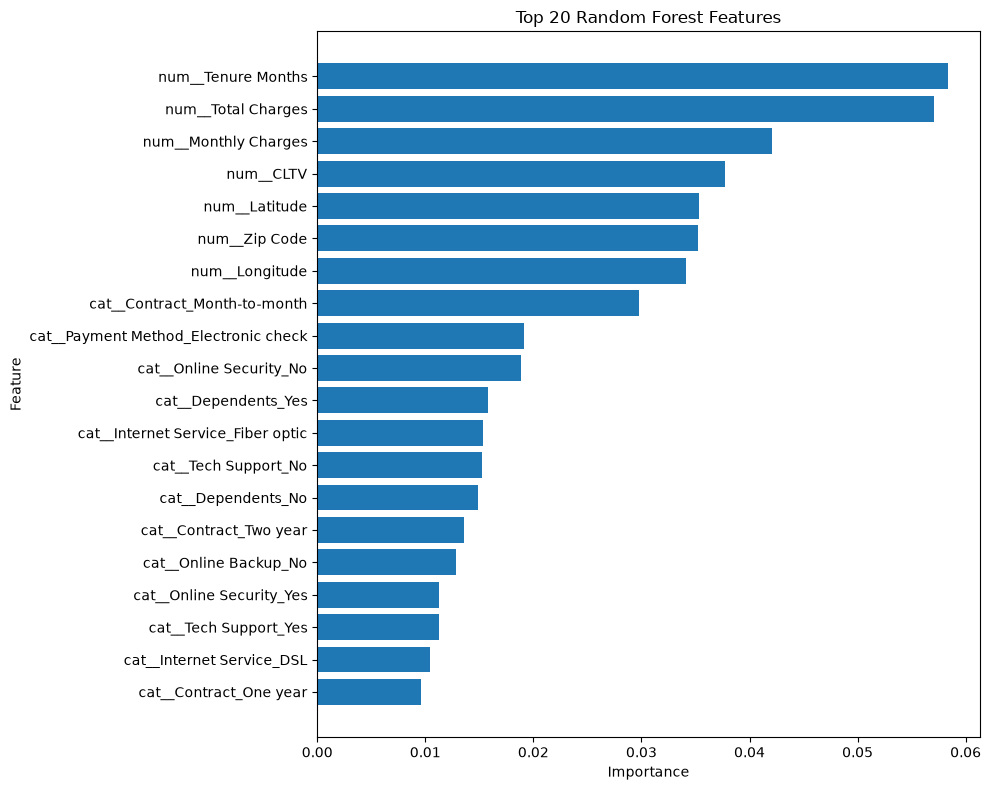

In [ ]:
top_features = importance_df.head(20).sort_values("Importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features["Feature"],top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Features")
plt.tight_layout()
plt.show()